In [1]:
import os
import uproot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import awkward as ak # Using awkward array for easier handling of jagged data
import time # For timing steps

def load_root_file(file_path, branches=None, print_branches=False):
    all_branches = {}
    with uproot.open(file_path) as file:
        tree = file["tree"]
        # Load all ROOT branches into array if not specified
        if branches is None:
            branches = tree.keys()
        # Option to print the branch names
        if print_branches:
            print("Branches:", tree.keys())
        # Each branch is added to the dictionary
        for branch in branches:
            try:
                all_branches[branch] = (tree[branch].array(library="np"))
            except uproot.KeyInFileError as e:
                print(f"KeyInFileError: {e}")
        # Number of events in file
        all_branches['event'] = tree.num_entries
    return all_branches

branches_list = [
    't5_innerRadius',
    't5_bridgeRadius',
    't5_outerRadius',
    't5_pt',
    't5_eta',
    't5_phi',
    't5_isFake',
    't5_t3_idx0',
    't5_t3_idx1',

    't5_t3_fakeScore1',
    't5_t3_promptScore1',
    't5_t3_displacedScore1',
    't5_t3_fakeScore2',
    't5_t3_promptScore2',
    't5_t3_displacedScore2',

    't5_pMatched',
    't5_sim_vxy',
    't5_sim_vz',
    't5_matched_simIdx'
]

# Hit-dependent branches
suffixes = ['r', 'z', 'eta', 'phi', 'layer']
branches_list += [f't5_t3_{i}_{suffix}' for i in [0, 2, 4] for suffix in suffixes]

file_path = "t5_embed_500.root"
branches = load_root_file(file_path, branches_list, print_branches=True)

Branches: ['sim_pt', 'sim_eta', 'sim_phi', 'sim_pca_dxy', 'sim_pca_dz', 'sim_q', 'sim_event', 'sim_pdgId', 'sim_vx', 'sim_vy', 'sim_vz', 'sim_trkNtupIdx', 'sim_TC_matched', 'sim_TC_matched_mask', 'tc_pt', 'tc_eta', 'tc_phi', 'tc_type', 'tc_isFake', 'tc_isDuplicate', 'tc_matched_simIdx', 'sim_dummy', 'tc_dummy', 'pT5_matched_simIdx', 'pT5_hitIdxs', 'sim_pT5_matched', 'pT5_pt', 'pT5_eta', 'pT5_phi', 'pT5_isFake', 't5_sim_vxy', 't5_sim_vz', 'pT5_isDuplicate', 'pT5_score', 'pT5_layer_binary', 'pT5_moduleType_binary', 'pT5_matched_pt', 'pT5_rzChiSquared', 'pT5_rPhiChiSquared', 'pT5_rPhiChiSquaredInwards', 'sim_pT3_matched', 'pT3_pt', 'pT3_isFake', 'pT3_isDuplicate', 'pT3_eta', 'pT3_phi', 'pT3_score', 'pT3_foundDuplicate', 'pT3_matched_simIdx', 'pT3_hitIdxs', 'pT3_pixelRadius', 'pT3_pixelRadiusError', 'pT3_matched_pt', 'pT3_tripletRadius', 'pT3_rPhiChiSquared', 'pT3_rPhiChiSquaredInwards', 'pT3_rzChiSquared', 'pT3_layer_binary', 'pT3_moduleType_binary', 'sim_pLS_matched', 'sim_pLS_types', 'p

In [3]:
z_max = np.max([np.max(event) for event in branches[f't5_t3_4_z']])
r_max = np.max([np.max(event) for event in branches[f't5_t3_4_r']])
eta_max = 2.5
phi_max = np.pi
n_events = np.shape(branches['t5_pt'])[0]

print(f'Z max: {z_max}, R max: {r_max}, Eta max: {eta_max}')

def delta_phi(phi1, phi2):
    delta = phi1 - phi2
    # Adjust delta to be within the range [-pi, pi]
    if delta > np.pi:
        delta -= 2 * np.pi
    elif delta < -np.pi:
        delta += 2 * np.pi
    return delta

Z max: 267.2349853515625, R max: 110.10993957519531, Eta max: 2.5


In [4]:
pMATCHED_THRESHOLD = 0.        # keep if t5_pMatched ≥ this
print(f"\nBuilding T5 features  (pMatched ≥ {pMATCHED_THRESHOLD}) …")

features_per_event    = []
eta_per_event         = []
displaced_per_event = []
sim_indices_per_event = []

kept_tot, init_tot = 0, 0
for ev in range(n_events):

    n_t5 = len(branches['t5_t3_idx0'][ev])
    init_tot += n_t5
    if n_t5 == 0:
        continue

    feat_evt = []
    eta_evt  = []
    sim_evt  = []
    disp_evt = []

    for i in range(n_t5):

        # pMatched filter ------------------------------------------------------
        if branches['t5_pMatched'][ev][i] < pMATCHED_THRESHOLD:
            continue

        # constituent triplet indices -----------------------------------------
        idx0 = branches['t5_t3_idx0'][ev][i]
        idx1 = branches['t5_t3_idx1'][ev][i]

        # hit-level quantities -------------------------------------------------
        eta1 = (branches['t5_t3_0_eta'][ev][idx0])
        eta2 = abs(branches['t5_t3_2_eta'][ev][idx0])
        eta3 = abs(branches['t5_t3_4_eta'][ev][idx0])
        eta4 = abs(branches['t5_t3_2_eta'][ev][idx1])
        eta5 = abs(branches['t5_t3_4_eta'][ev][idx1])

        phi1 = branches['t5_t3_0_phi'][ev][idx0]
        phi2 = branches['t5_t3_2_phi'][ev][idx0]
        phi3 = branches['t5_t3_4_phi'][ev][idx0]
        phi4 = branches['t5_t3_2_phi'][ev][idx1]
        phi5 = branches['t5_t3_4_phi'][ev][idx1]

        z1 = abs(branches['t5_t3_0_z'][ev][idx0])
        z2 = abs(branches['t5_t3_2_z'][ev][idx0])
        z3 = abs(branches['t5_t3_4_z'][ev][idx0])
        z4 = abs(branches['t5_t3_2_z'][ev][idx1])
        z5 = abs(branches['t5_t3_4_z'][ev][idx1])

        r1 = branches['t5_t3_0_r'][ev][idx0]
        r2 = branches['t5_t3_2_r'][ev][idx0]
        r3 = branches['t5_t3_4_r'][ev][idx0]
        r4 = branches['t5_t3_2_r'][ev][idx1]
        r5 = branches['t5_t3_4_r'][ev][idx1]

        inR  = branches['t5_innerRadius' ][ev][i]
        brR  = branches['t5_bridgeRadius'][ev][i]
        outR = branches['t5_outerRadius' ][ev][i]

        s1_fake   = branches['t5_t3_fakeScore1'     ][ev][i]
        s1_prompt = branches['t5_t3_promptScore1'   ][ev][i]
        s1_disp   = branches['t5_t3_displacedScore1'][ev][i]
        d_fake    = branches['t5_t3_fakeScore2'     ][ev][i] - s1_fake
        d_prompt  = branches['t5_t3_promptScore2'   ][ev][i] - s1_prompt
        d_disp    = branches['t5_t3_displacedScore2'][ev][i] - s1_disp

        f = [
            eta1 / eta_max,
            np.cos(phi1),
            np.sin(phi1),
            z1 / z_max,
            r1 / r_max,

            eta2 - abs(eta1),
            delta_phi(phi2, phi1),
            (z2 - z1) / z_max,
            (r2 - r1) / r_max,

            eta3 - eta2,
            delta_phi(phi3, phi2),
            (z3 - z2) / z_max,
            (r3 - r2) / r_max,

            eta4 - eta3,
            delta_phi(phi4, phi3),
            (z4 - z3) / z_max,
            (r4 - r3) / r_max,

            eta5 - eta4,
            delta_phi(phi5, phi4),
            (z5 - z4) / z_max,
            (r5 - r4) / r_max,

            np.log10(inR),
            np.log10(brR),
            np.log10(outR),

            s1_fake, s1_prompt, s1_disp,
            d_fake,  d_prompt,  d_disp
        ]
        feat_evt.append(f)
        eta_evt.append(eta1)
        disp_evt.append(branches['t5_sim_vxy'][ev][i])

        # first (or only) matched sim-index, -1 if none -----------------------
        simIdx_list = branches['t5_matched_simIdx'][ev][i]
        sim_evt.append(simIdx_list[0] if len(simIdx_list) else -1)

    # push to global containers ----------------------------------------------
    if feat_evt:                                # skip events with no survivors
        features_per_event.append(np.asarray(feat_evt, dtype=np.float32))
        eta_per_event.append(np.asarray(eta_evt,  dtype=np.float32))
        displaced_per_event.append(np.asarray(disp_evt, dtype=np.float32))
        sim_indices_per_event.append(np.asarray(sim_evt, dtype=np.int64))
        kept_tot += len(feat_evt)

print(f"\nKept {kept_tot} / {init_tot} T5s "
      f"({kept_tot/init_tot*100:.2f} %) that passed the pMatched cut.")
print(f"Total events with ≥1 kept T5: {len(features_per_event)}")


Building T5 features  (pMatched ≥ 0.0) …

Kept 3630781 / 3630781 T5s (100.00 %) that passed the pMatched cut.
Total events with ≥1 kept T5: 500


In [5]:
import time, random, math, numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed
from sklearn.model_selection import train_test_split

DELTA_R2_CUT = 0.02

# ---------------------------------------------------------------------------
def _delta_phi(phi1, phi2):
    """same helper you already defined, but inline for the worker"""
    d = phi1 - phi2
    if d > math.pi:
        d -= 2 * math.pi
    elif d < -math.pi:
        d += 2 * math.pi
    return d
# ---------------------------------------------------------------------------
def _pairs_single_event(evt_idx,
                        F, S, D,
                        max_sim, max_dis,
                        invalid_sim):
    """
    Worker run in a separate process.
    Returns two Python lists with the selected (i,j) indices per event.
    """
    n = F.shape[0]
    if n < 2:
        return evt_idx, [], []

    eta1 = F[:, 0] * eta_max
    phi1 = np.arctan2(F[:, 2], F[:, 1])

    sim_pairs, dis_pairs = [], []

    # similar pairs (same sim-index)
    buckets = {}
    for idx, s in enumerate(S):
        if s != invalid_sim:
            buckets.setdefault(s, []).append(idx)

    for lst in buckets.values():
        if len(lst) < 2:
            continue
        for a in range(len(lst) - 1):
            i = lst[a]
            for b in range(a + 1, len(lst)):
                j = lst[b]
                dphi = _delta_phi(phi1[i], phi1[j])
                dr2  = (eta1[i] - eta1[j])**2 + dphi**2
                if dr2 < DELTA_R2_CUT:
                    sim_pairs.append((i, j))

    # dissimilar pairs (different sim)
    for i in range(n - 1):
        si, ei, pi = S[i], eta1[i], phi1[i]
        for j in range(i + 1, n):
            if (si == S[j]) and si != invalid_sim:
                continue
            dphi = _delta_phi(pi, phi1[j])
            dr2  = (ei - eta1[j])**2 + dphi**2
            if dr2 < DELTA_R2_CUT:
                dis_pairs.append((i, j))

    # down-sample
    if len(sim_pairs) > max_sim:
        sim_pairs = random.sample(sim_pairs, max_sim)
    if len(dis_pairs) > max_dis:
        dis_pairs = random.sample(dis_pairs, max_dis)

    print(f"[evt {evt_idx:4d}]  T5s={n:5d}  sim={len(sim_pairs):3d}  dis={len(dis_pairs):3d}")
    return evt_idx, sim_pairs, dis_pairs

# ---------------------------------------------------------------------------
def create_t5_pairs_balanced_parallel(features_per_event,
                                      sim_indices_per_event,
                                      displaced_per_event,
                                      *,
                                      max_similar_pairs_per_event=100,
                                      max_dissimilar_pairs_per_event=450,
                                      invalid_sim_idx=-1,
                                      n_workers=None):
    t0 = time.time()
    print("\n>>> Pair generation  (ΔR² < 0.02)  –  parallel mode")

    work_args = [
        (evt_idx,
         features_per_event[evt_idx],
         sim_indices_per_event[evt_idx],
         displaced_per_event[evt_idx],
         max_similar_pairs_per_event,
         max_dissimilar_pairs_per_event,
         invalid_sim_idx)
        for evt_idx in range(len(features_per_event))
    ]

    sim_L, sim_R, sim_disp = [], [], []
    dis_L, dis_R, dis_disp = [], [], []

    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        futures = [pool.submit(_pairs_single_event, *args) for args in work_args]
        for fut in as_completed(futures):
            evt_idx, sim_pairs_evt, dis_pairs_evt = fut.result()
            F = features_per_event[evt_idx]
            D = displaced_per_event[evt_idx]

            for i, j in sim_pairs_evt:
                sim_L.append(F[i])
                sim_R.append(F[j])
                sim_disp.append(D[i] > 0.1 or D[j] > 0.1)

            for i, j in dis_pairs_evt:
                dis_L.append(F[i])
                dis_R.append(F[j])
                dis_disp.append(D[i] > 0.1 or D[j] > 0.1)

    X_left  = np.concatenate([np.asarray(sim_L, dtype=np.float32),
                              np.asarray(dis_L, dtype=np.float32)], axis=0)
    X_right = np.concatenate([np.asarray(sim_R, dtype=np.float32),
                              np.asarray(dis_R, dtype=np.float32)], axis=0)
    y       = np.concatenate([np.zeros(len(sim_L), dtype=np.int32),
                              np.ones (len(dis_L), dtype=np.int32)])

    disp_L = np.concatenate([np.asarray(sim_disp, dtype=bool),
                             np.asarray(dis_disp, dtype=bool)], axis=0)
    disp_R = disp_L.copy()

    print(f"<<< done in {time.time() - t0:.1f}s  | sim {len(sim_L)}  dis {len(dis_L)}  total {len(y)}")
    return X_left, X_right, y, disp_L, disp_R

# invoke
X_left, X_right, y, disp_L, disp_R = create_t5_pairs_balanced_parallel(
    features_per_event,
    sim_indices_per_event,
    displaced_per_event,
    max_similar_pairs_per_event    = 1000,
    max_dissimilar_pairs_per_event = 1000,
    invalid_sim_idx                = -1,
    n_workers                      = None
)

if len(y) == 0:
    raise ValueError("No pairs generated. Check filters/data.")

mask = (np.isfinite(X_left).all(axis=1) &
        np.isfinite(X_right).all(axis=1))
if not mask.all():
    print(f"Filtering {np.sum(~mask)} pairs with NaN/Inf")
    X_left, X_right, y, disp_L, disp_R = X_left[mask], X_right[mask], y[mask], disp_L[mask], disp_R[mask]

print("\nSplitting into train / test sets…")
X_left_train, X_left_test, \
X_right_train, X_right_test, \
y_train, y_test, \
disp_L_train, disp_L_test, \
disp_R_train, disp_R_test = train_test_split(
    X_left, X_right, y, disp_L, disp_R,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y if np.unique(y).size > 1 else None,
    shuffle      = True
)
print(f"Split complete: train {len(y_train)}, test {len(y_test)}")

# compute displaced fraction
pct_disp = np.mean(disp_L | disp_R) * 100
print(f"{pct_disp:.2f}% of all pairs involve a displaced T5")


>>> Pair generation  (ΔR² < 0.02)  –  parallel mode
[evt    0]  T5s= 3864  sim=1000  dis=1000
[evt  169]  T5s= 3914  sim=1000  dis=1000
[evt  149]  T5s= 4510  sim=1000  dis=1000
[evt    2]  T5s= 4648  sim=1000  dis=1000
[evt  128]  T5s= 4777  sim=1000  dis=1000
[evt    1]  T5s= 4786  sim=1000  dis=1000
[evt   33]  T5s= 4853  sim=1000  dis=1000
[evt   53]  T5s= 5146  sim=1000  dis=1000
[evt  189]  T5s= 5170  sim=1000  dis=1000
[evt  138]  T5s= 5303  sim=1000  dis=1000
[evt   75]  T5s= 5300  sim=1000  dis=1000
[evt   72]  T5s= 5337  sim=1000  dis=1000
[evt    6]  T5s= 5333  sim=1000  dis=1000
[evt  177]  T5s= 5441  sim=1000  dis=1000
[evt  155]  T5s= 5492  sim=1000  dis=1000
[evt  117]  T5s= 5534  sim=1000  dis=1000
[evt   85]  T5s= 5553  sim=1000  dis=1000
[evt  113]  T5s= 5666  sim=1000  dis=1000
[evt   71]  T5s= 5685  sim=1000  dis=1000
[evt   87]  T5s= 5685  sim=1000  dis=1000
[evt  181]  T5s= 5707  sim=1000  dis=1000
[evt   88]  T5s= 5714  sim=1000  dis=1000
[evt   46]  T5s= 5820  

In [6]:
print("\nCreating PyTorch Datasets and DataLoaders...")

class SiameseDataset(Dataset):
    def __init__(self, X_left, X_right, y, w):
        if not isinstance(X_left, np.ndarray):  X_left  = np.array(X_left)
        if not isinstance(X_right, np.ndarray): X_right = np.array(X_right)
        if not isinstance(y, np.ndarray):       y       = np.array(y)
        if not isinstance(w, np.ndarray):       w       = np.array(w)
        self.X_left  = torch.from_numpy(X_left .astype(np.float32))
        self.X_right = torch.from_numpy(X_right.astype(np.float32))
        self.y       = torch.from_numpy(y      .astype(np.float32)).view(-1,1)
        self.w       = torch.from_numpy(w      .astype(np.float32)).view(-1,1)
    def __len__(self): 
        return len(self.y)
    def __getitem__(self, idx):
        return self.X_left[idx], self.X_right[idx], self.y[idx], self.w[idx]

batch_size = 1024

# build per-pair weights: displaced pairs get weight=5.0
weights_train = np.where(disp_L_train | disp_R_train, 5.0, 1.0)
weights_test  = np.where(disp_L_test  | disp_R_test,  5.0, 1.0)

train_dataset = SiameseDataset(X_left_train, X_right_train, y_train, weights_train)
test_dataset  = SiameseDataset(X_left_test,  X_right_test,  y_test,  weights_test)

try:
    num_workers = min(os.cpu_count(), 8) if os.cpu_count() else 4
except NotImplementedError:
    num_workers = 4
    print("os.cpu_count() failed, using 4 workers.")
print(f"Using {num_workers} workers for DataLoader.")

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers>0)
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers>0)
)
print("DataLoaders created.")


Creating PyTorch Datasets and DataLoaders...
Using 8 workers for DataLoader.
DataLoaders created.


In [7]:
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim=30, embedding_dim=6):
        super(EmbeddingNet, self).__init__()
        self.input_dim = input_dim
        self.embedding_dim = embedding_dim
        self.fc1 = nn.Linear(input_dim, 32)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(32, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, embedding_dim)
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

class SiameseNet(nn.Module):
    def __init__(self, embedding_net):
        super(SiameseNet, self).__init__()
        self.embedding_net = embedding_net
    def forward(self, x1, x2):
        o1 = self.embedding_net(x1)
        o2 = self.embedding_net(x2)
        # Euclidean distance
        return torch.sqrt(((o1 - o2)**2).sum(dim=1, keepdim=True) + 1e-6)

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
    def forward(self, d, label, weight=None):
        # d: [B,1], label: [B,1], weight: [B,1] or None
        l_sim = (1 - label) * d.pow(2)
        l_dis = label * (self.margin - d).clamp(min=0.0).pow(2)
        loss = l_sim + l_dis
        if weight is not None:
            loss = loss * weight
        return loss.mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
input_dim, embedding_dim = 30, 6
embedding_net = EmbeddingNet(input_dim, embedding_dim).to(device)
model = SiameseNet(embedding_net).to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=0.0025)


Using device: cuda


In [8]:
num_epochs = 200
train_losses, val_losses = [], []
best_val_loss = float('inf')
model_save_path = f'best_t3_siamese_model_pT{pMATCHED_THRESHOLD}.pth'

print("\n--- Starting Training ---")
start_train_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    model.train()
    running_loss = 0.0

    for batch_idx, (batch_left, batch_right, batch_label, batch_weight) in enumerate(train_loader):
        batch_left, batch_right = batch_left.to(device), batch_right.to(device)
        batch_label, batch_weight = batch_label.to(device), batch_weight.to(device)

        optimizer.zero_grad()
        distances = model(batch_left, batch_right)
        loss = criterion(distances, batch_label, batch_weight)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_left.size(0)

    epoch_loss = running_loss / len(train_loader.dataset) if len(train_loader.dataset) > 0 else 0.0
    train_losses.append(epoch_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_left, batch_right, batch_label, batch_weight in test_loader:
            batch_left, batch_right = batch_left.to(device), batch_right.to(device)
            batch_label, batch_weight = batch_label.to(device), batch_weight.to(device)
            distances = model(batch_left, batch_right)
            loss = criterion(distances, batch_label, batch_weight)
            running_val_loss += loss.item() * batch_left.size(0)

    epoch_val_loss = running_val_loss / len(test_loader.dataset) if len(test_loader.dataset) > 0 else 0.0
    val_losses.append(epoch_val_loss)

    epoch_duration = time.time() - epoch_start_time
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.5f} - Val Loss: {epoch_val_loss:.5f} - Time: {epoch_duration:.2f}s")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), model_save_path)
        print(f"  Saved best model (Val Loss: {best_val_loss:.5f}) to {model_save_path}")

end_train_time = time.time()
print(f"Training finished. Total time: {end_train_time - start_train_time:.2f}s.")
if os.path.exists(model_save_path):
    print(f"Loading best model from {model_save_path} for evaluation.")
    try:
        model.load_state_dict(torch.load(model_save_path, map_location=device))
    except Exception as e:
        print(f"Error loading model: {e}. Using last state.")
else:
    print(f"Warning: Model file {model_save_path} not found.")


--- Starting Training ---
Epoch 1/200 - Train Loss: 0.20499 - Val Loss: 0.15461 - Time: 2.23s
  Saved best model (Val Loss: 0.15461) to best_t3_siamese_model_pT0.0.pth
Epoch 2/200 - Train Loss: 0.14510 - Val Loss: 0.13850 - Time: 1.61s
  Saved best model (Val Loss: 0.13850) to best_t3_siamese_model_pT0.0.pth
Epoch 3/200 - Train Loss: 0.13496 - Val Loss: 0.13023 - Time: 1.62s
  Saved best model (Val Loss: 0.13023) to best_t3_siamese_model_pT0.0.pth
Epoch 4/200 - Train Loss: 0.12873 - Val Loss: 0.12554 - Time: 1.64s
  Saved best model (Val Loss: 0.12554) to best_t3_siamese_model_pT0.0.pth
Epoch 5/200 - Train Loss: 0.12502 - Val Loss: 0.12414 - Time: 3.05s
  Saved best model (Val Loss: 0.12414) to best_t3_siamese_model_pT0.0.pth
Epoch 6/200 - Train Loss: 0.12185 - Val Loss: 0.11920 - Time: 1.59s
  Saved best model (Val Loss: 0.11920) to best_t3_siamese_model_pT0.0.pth
Epoch 7/200 - Train Loss: 0.11943 - Val Loss: 0.11880 - Time: 1.59s
  Saved best model (Val Loss: 0.11880) to best_t3_sia


--- Evaluating Model ---
Evaluation data collection took: 0.23s.
Evaluation complete. Collected 200000 distances.
Test distances range: Min=0.0010, Max=17.5420


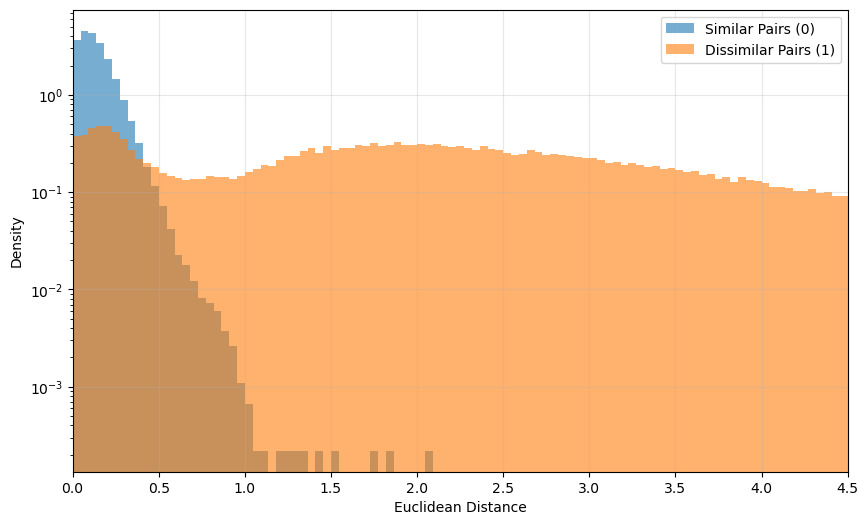

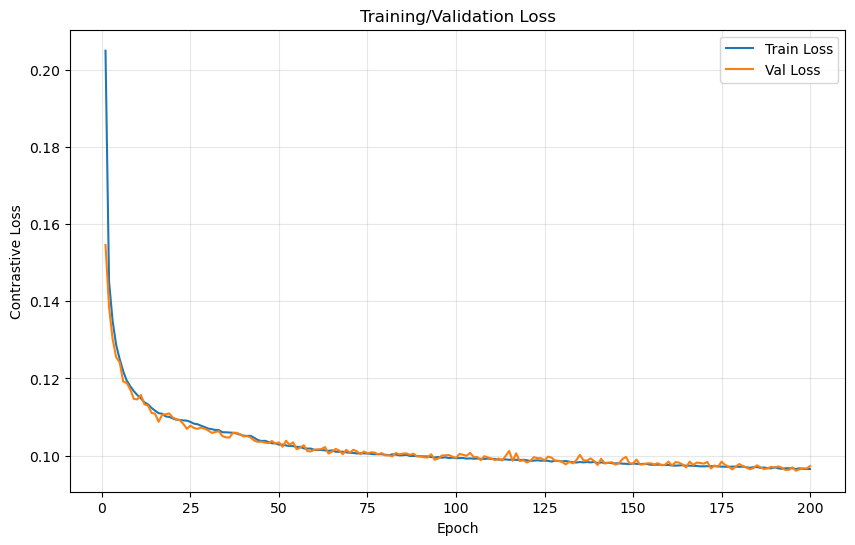

In [27]:
print("\n--- Evaluating Model ---")
model.eval(); all_distances, all_labels = [], []
eval_start_time = time.time()
with torch.no_grad(): # (Evaluation loop unchanged)
    for batch_left, batch_right, batch_label, _ in test_loader:
        batch_left, batch_right = batch_left.to(device), batch_right.to(device)
        distances = model(batch_left, batch_right)
        all_distances.append(distances.cpu().numpy()); all_labels.append(batch_label.numpy())
eval_end_time = time.time(); print(f"Evaluation data collection took: {eval_end_time - eval_start_time:.2f}s.")

if not all_distances: print("Error: No distances collected.")
else: # (Plotting logic unchanged, filenames updated)
    all_distances, all_labels = np.concatenate(all_distances).flatten(), np.concatenate(all_labels).flatten()
    print(f"Evaluation complete. Collected {len(all_distances)} distances.")
    if len(all_distances) == 0: print("No test data to plot.")
    else:
        print(f"Test distances range: Min={all_distances.min():.4f}, Max={all_distances.max():.4f}")

        # Plot 1: Distances
        plt.figure(figsize=(10, 6))
        bins = np.linspace(all_distances.min(), 4.5, 100)
        plt.hist(all_distances[all_labels == 0], bins=bins, alpha=0.6, density=True, label='Similar Pairs (0)', range=(0,4.5))
        plt.hist(all_distances[all_labels == 1], bins=bins, alpha=0.6, density=True, label='Dissimilar Pairs (1)', range=(0,4.5))
        plt.xlabel("Euclidean Distance")
        plt.ylabel("Density")
        #plt.xticks(np.arange(0, 5, 0.5))  # Set x ticks at 0, 0.5, 1, ..., 4.5
        plt.legend()
        plt.yscale('log')
        #plt.xscale('log')
        plt.grid(True, alpha=0.3)
        plt.xlim([0,4.5])
        plt.show()

        # Plot 2: Loss
        plt.figure(figsize=(10, 6))
        if train_losses: plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
        if val_losses: plt.plot(range(1, len(val_losses) + 1), val_losses, label='Val Loss')
        plt.xlabel("Epoch"); plt.ylabel("Contrastive Loss"); plt.title("Training/Validation Loss")
        if train_losses or val_losses: plt.legend(); plt.grid(True, alpha=0.3)
        plt.show()


In [10]:
def print_formatted_weights_biases(weights, biases, layer_name):
    # Print biases
    print(f"HOST_DEVICE_CONSTANT float bias_{layer_name}[{len(biases)}] = {{")
    print(", ".join(f"{b:.7f}f" for b in biases) + " };")
    print()

    # Print weights
    print(f"HOST_DEVICE_CONSTANT const float wgtT_{layer_name}[{len(weights[0])}][{len(weights)}] = {{")
    for row in weights.T:
        formatted_row = ", ".join(f"{w:.7f}f" for w in row)
        print(f"{{ {formatted_row} }},")
    print("};")
    print()

def print_model_weights_biases(model):
    # Make sure the model is in evaluation mode
    model.eval()

    # Iterate through all named modules in the model
    for name, module in model.named_modules():
        # Check if the module is a linear layer
        if isinstance(module, nn.Linear):
            # Get weights and biases
            weights = module.weight.data.cpu().numpy()
            biases = module.bias.data.cpu().numpy()

            # Print formatted weights and biases
            print_formatted_weights_biases(weights, biases, name.replace('.', '_'))

print_model_weights_biases(model.embedding_net)


HOST_DEVICE_CONSTANT float bias_fc1[32] = {
-0.9598878f, 0.0878039f, 1.7896566f, 0.5146632f, -0.0162605f, 0.4588976f, 0.0213260f, 1.3909615f, -0.1484435f, -0.8754486f, 0.0465658f, -0.1515206f, 0.7644885f, 0.6442893f, 1.3355688f, 0.0158414f, -0.0777233f, 0.0033272f, 0.1334810f, 0.0090908f, -0.0828567f, -0.3060022f, 0.5463116f, -1.8017302f, 0.1705165f, -0.7197251f, -0.7793315f, -1.7447037f, 0.2618848f, -0.1740292f, 0.5227864f, 0.0617760f };

HOST_DEVICE_CONSTANT const float wgtT_fc1[30][32] = {
{ -0.0069432f, -0.0004147f, 0.0114648f, -0.0501221f, -0.1268186f, -0.0261487f, 0.0995848f, -0.0082367f, 0.0371357f, 0.0201904f, 0.0156629f, -0.1166645f, -0.0238351f, 0.0042578f, -0.0342939f, 0.0462179f, -0.1776737f, -0.1698786f, 0.0060219f, -0.1271834f, -0.1318914f, -0.0379743f, -0.0028704f, 0.0059029f, -0.0786194f, -0.0002085f, -0.0066507f, -0.0030552f, -0.0317778f, -0.0570465f, -0.0162881f, 0.1635776f },
{ 0.0008184f, -0.0121548f, -0.0128656f, -0.0007862f, -0.1296187f, 0.0211281f, -0.0672694f, -

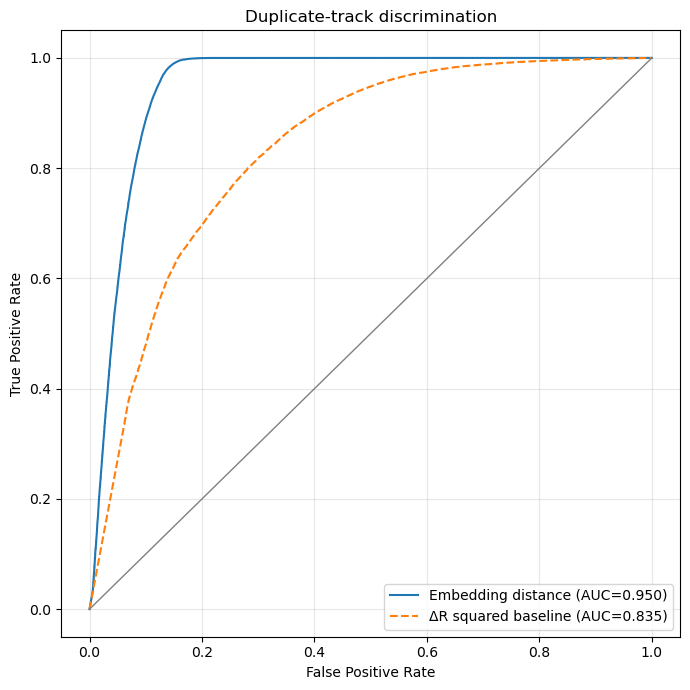

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    return dphi

# 1) geometric ΔR
phi_left  = np.arctan2(X_left_test[:,2],  X_left_test[:,1])
phi_right = np.arctan2(X_right_test[:,2], X_right_test[:,1])
dphi = delta_phi(phi_left, phi_right)
deta = (X_left_test[:,0] - X_right_test[:,0]) * eta_max
dR = np.sqrt(deta**2 + dphi**2)
dRsq = deta**2 + dphi**2

# 2) ROC curves, declaring label 0 as “positive” (= duplicates)
fpr_dr,  tpr_dr,  _ = roc_curve(y_test, -dRsq,            pos_label=0)
fpr_dnn, tpr_dnn, _ = roc_curve(y_test, -all_distances, pos_label=0)

auc_dr  = auc(fpr_dr,  tpr_dr)
auc_dnn = auc(fpr_dnn, tpr_dnn)

# 3) plot
plt.figure(figsize=(7,7))
plt.plot(fpr_dnn, tpr_dnn, label=f"Embedding distance (AUC={auc_dnn:.3f})")
plt.plot(fpr_dr,  tpr_dr,  '--', label=f"ΔR squared baseline (AUC={auc_dr:.3f})")
plt.plot([0,1],[0,1],color='grey',lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Duplicate-track discrimination")
#plt.xscale('log')
plt.grid(True,alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

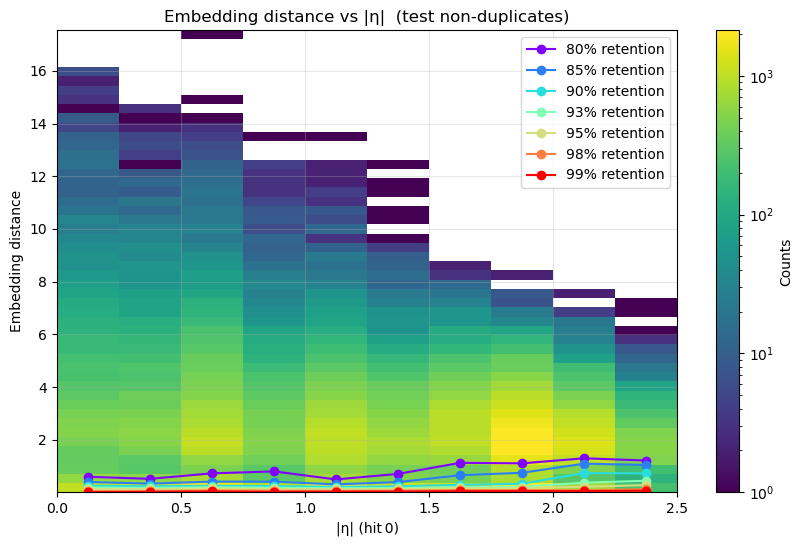

80%-cut: { 0.5865f, 0.5100f, 0.7177f, 0.7910f, 0.4876f, 0.6968f, 1.1163f, 1.0972f, 1.2892f, 1.2050f } 
  80%-dupRej: { 98.70, 98.40, 99.87, 99.97, 98.33, 99.56, 100.00, 100.00, 100.00, 100.00 }
85%-cut: { 0.3909f, 0.3270f, 0.4052f, 0.4009f, 0.3000f, 0.3844f, 0.6476f, 0.7385f, 1.0849f, 1.0382f } 
  85%-dupRej: { 92.46, 89.86, 97.25, 97.86, 88.48, 95.69, 99.66, 99.89, 100.00, 100.00 }
90%-cut: { 0.2490f, 0.2250f, 0.2473f, 0.2335f, 0.2049f, 0.2242f, 0.2815f, 0.3233f, 0.7301f, 0.7152f } 
  90%-dupRej: { 73.16, 72.59, 82.38, 80.46, 69.53, 76.13, 91.36, 97.02, 99.97, 99.91 }
93%-cut: { 0.1788f, 0.1641f, 0.1889f, 0.1702f, 0.1523f, 0.1583f, 0.1956f, 0.2079f, 0.3638f, 0.4363f } 
  93%-dupRej: { 54.49, 55.29, 67.32, 62.62, 52.25, 57.41, 76.19, 85.03, 99.62, 99.73 }
95%-cut: { 0.1243f, 0.1249f, 0.1429f, 0.1279f, 0.1156f, 0.1257f, 0.1508f, 0.1527f, 0.2094f, 0.2708f } 
  95%-dupRej: { 38.49, 42.22, 50.41, 46.47, 39.04, 44.67, 61.53, 68.13, 95.42, 98.01 }
98%-cut: { 0.0351f, 0.0460f, 0.0659f, 0.0537

In [37]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- CONFIG -----------------------------------------------------------------
percentiles   = [80, 85, 90, 93, 95, 98, 99]          # keep these % of non‑duplicates
eta_edges     = np.arange(0.0, 2.75, 0.25)
dr2_threshold = 1.0e-3                # ΔR² cut

# --- PREPARE TEST‑SET ARRAYS -------------------------------------------------
# geometry of hit‑0
eta_L  = X_left_test[:, 0] * eta_max
phi_L  = np.arctan2(X_left_test[:, 2], X_left_test[:, 1])
eta_R  = X_right_test[:, 0] * eta_max
phi_R  = np.arctan2(X_right_test[:, 2], X_right_test[:, 1])

abs_eta = np.abs(eta_L)

# ΔR² for each pair
deta  = eta_L - eta_R
dphi  = (phi_R - phi_L + np.pi) % (2*np.pi) - np.pi
dR2   = deta**2 + dphi**2

# embedding distances
model.eval()
with torch.no_grad():
    L = torch.from_numpy(X_left_test.astype(np.float32)).to(device)
    R = torch.from_numpy(X_right_test.astype(np.float32)).to(device)
    dist = model(L, R).cpu().numpy().flatten()

# --- LOOP OVER |η| BINS ------------------------------------------------------
cut_vals   = {p: [] for p in percentiles}   # distance cuts
dup_rej    = {p: [] for p in percentiles}   # duplicate rejection at those cuts
dr2_eff    = []                             # non‑dup kept by ΔR²
dr2_rejdup = []                             # dup rejected by ΔR²

for lo, hi in zip(eta_edges[:-1], eta_edges[1:]):
    nnd = (abs_eta >= lo) & (abs_eta < hi) & (y_test == 1)  # non‑dups
    dup = (abs_eta >= lo) & (abs_eta < hi) & (y_test == 0)  # dups

    # ΔR² metrics
    dr2_eff.append(np.mean(dR2[nnd] >= dr2_threshold)*100 if np.any(nnd) else np.nan)
    dr2_rejdup.append(np.mean(dR2[dup] < dr2_threshold)*100 if np.any(dup) else np.nan)

    # embedding‑distance cuts
    for p in percentiles:
        cut = np.percentile(dist[nnd], 100-p) if np.any(nnd) else np.nan
        cut_vals[p].append(cut)
        dup_rej[p].append(np.mean(dist[dup] < cut)*100 if (np.any(dup) and not np.isnan(cut)) else np.nan)

# --- PLOT --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10,6))
h = ax.hist2d(abs_eta[y_test==1], dist[y_test==1],
              bins=[eta_edges, 50], norm=LogNorm())
fig.colorbar(h[3], ax=ax, label='Counts')
ax.set_xlabel('|η| (hit 0)')
ax.set_ylabel('Embedding distance')
ax.set_title('Embedding distance vs |η|  (test non‑duplicates)')

mid_eta  = eta_edges[:-1] + 0.5*np.diff(eta_edges)
for p, clr in zip(percentiles, plt.cm.rainbow(np.linspace(0,1,len(percentiles)))):
    ax.plot(mid_eta, cut_vals[p], '-o', color=clr, label=f'{p}% retention')
ax.legend(); ax.grid(alpha=0.3); plt.show()


for p in percentiles:
    cuts   = ", ".join(f"{v:.4f}f" for v in cut_vals[p])
    rejs   = ", ".join(f"{v:.2f}"    for v in dup_rej[p])
    print(f"{p}%-cut: {{ {cuts} }} \n  {p}%-dupRej: {{ {rejs} }}")

eff  = ", ".join(f"{v:.2f}" if not np.isnan(v) else "nan" for v in dr2_eff)
rej  = ", ".join(f"{v:.2f}" if not np.isnan(v) else "nan" for v in dr2_rejdup)
print(f"dR2-eff (%): {{ {eff} }} \n  dR2-dupRej (%): {{ {rej} }}")